# EV2 - Proyecto de Machine Learning
## Caso: Google Play Store Apps

En este proyecto desarrollamos una solución de Machine Learning utilizando el dataset limpio de Google Play Store Apps trabajado en la EV1.

El objetivo principal es predecir si una aplicación puede alcanzar un rating alto, considerando características como categoría, cantidad de reseñas, instalaciones, tipo de aplicación, precio y clasificación de contenido.

Para esto, se implementarán modelos supervisados de clasificación, técnicas de preprocesamiento mediante pipelines, validación cruzada, comparación de métricas, optimización de hiperparámetros y un análisis no supervisado mediante clustering.

In [ ]:
# Librerías principales
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# División de datos y validación
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos supervisados
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Modelo no supervisado
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Configuración general
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("googleplaystore_limpio.csv")

print("Filas y columnas:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

df.head()

Filas y columnas: (10346, 13)

Tipos de datos:
App                object
Category           object
Rating            float64
Reviews             int64
Size               object
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

Valores nulos por columna:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

Duplicados:
0


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


Al cargar el dataset limpio se verifica su estructura general, incluyendo la cantidad de filas y columnas, los tipos de datos, la presencia de valores nulos y la existencia de registros duplicados.

Esta revisión permite confirmar que el archivo se encuentra en condiciones adecuadas para iniciar la etapa de modelamiento. Sin embargo, algunas variables continúan siendo categóricas, por lo que deberán ser transformadas posteriormente mediante técnicas como One-Hot Encoding dentro de un pipeline de preprocesamiento.

In [ ]:
# Selección de columnas útiles para el modelamiento inicial

columnas_modelo = [
    "Category",
    "Rating",
    "Reviews",
    "Installs",
    "Type",
    "Price",
    "Content Rating",
    "Genres"
]

df_modelo = df[columnas_modelo].copy()

df_modelo.head()

,Category,Rating,Reviews,Installs,Type,Price,Content Rating,Genres
0,ART_AND_DESIGN,4.1,159,10000,Free,0.0,Everyone,Art & Design
1,ART_AND_DESIGN,3.9,967,500000,Free,0.0,Everyone,Art & Design;Pretend Play
2,ART_AND_DESIGN,4.7,87510,5000000,Free,0.0,Everyone,Art & Design
3,ART_AND_DESIGN,4.5,215644,50000000,Free,0.0,Teen,Art & Design
4,ART_AND_DESIGN,4.3,967,100000,Free,0.0,Everyone,Art & Design;Creativity


## Creación de la variable objetivo

Para este proyecto se decidió transformar el problema en una tarea de clasificación supervisada.

La variable original `Rating` representa la calificación de cada aplicación. A partir de ella se creó una nueva variable llamada `Rating_Alto`, donde:

- 1 representa una aplicación con rating alto.
- 0 representa una aplicación con rating bajo o medio.

Se consideró como rating alto un valor igual o superior a 4.3, ya que en el análisis exploratorio previo se observó que gran parte de las aplicaciones se concentran en calificaciones cercanas a 4.0 y superiores.

In [ ]:
# Selección de columnas útiles para el modelamiento inicial

columnas_modelo = [
    "Category",
    "Rating",
    "Reviews",
    "Installs",
    "Type",
    "Price",
    "Content Rating",
    "Genres"
]

df_modelo = df[columnas_modelo].copy()

# Crear variable objetivo
df_modelo["Rating_Alto"] = df_modelo["Rating"].apply(lambda x: 1 if x >= 4.3 else 0)

# Revisar resultado
df_modelo.head()

,Category,Rating,Reviews,Installs,Type,Price,Content Rating,Genres,Rating_Alto
0,ART_AND_DESIGN,4.1,159,10000,Free,0.0,Everyone,Art & Design,0
1,ART_AND_DESIGN,3.9,967,500000,Free,0.0,Everyone,Art & Design;Pretend Play,0
2,ART_AND_DESIGN,4.7,87510,5000000,Free,0.0,Everyone,Art & Design,1
3,ART_AND_DESIGN,4.5,215644,50000000,Free,0.0,Teen,Art & Design,1
4,ART_AND_DESIGN,4.3,967,100000,Free,0.0,Everyone,Art & Design;Creativity,1


In [ ]:
# Distribución de la variable objetivo

print(df_modelo["Rating_Alto"].value_counts())

print("\nPorcentaje:")
print(df_modelo["Rating_Alto"].value_counts(normalize=True) * 100)

Rating_Alto
1    6321
0    4025
Name: count, dtype: int64

Porcentaje:
Rating_Alto
1    61.096076
0    38.903924
Name: proportion, dtype: float64


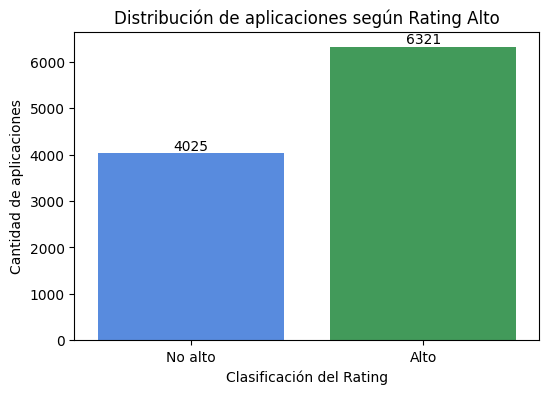

In [ ]:
# Gráfico de distribución de Rating_Alto con estilo Google

plt.figure(figsize=(6,4))

colores_google = ["#4285F4", "#34A853"]

ax = sns.countplot(
    data=df_modelo,
    x="Rating_Alto",
    palette=colores_google
)

plt.title("Distribución de aplicaciones según Rating Alto")
plt.xlabel("Clasificación del Rating")
plt.ylabel("Cantidad de aplicaciones")

plt.xticks([0, 1], ["No alto", "Alto"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

La variable objetivo `Rating_Alto` permite clasificar las aplicaciones según su nivel de calificación. En este caso, se identificaron 4.025 aplicaciones con rating no alto y 6.321 aplicaciones con rating alto.

Esto muestra que existe una mayor cantidad de aplicaciones bien evaluadas dentro del dataset, lo cual coincide con el comportamiento observado previamente en la EV1, donde la mayoría de los ratings se concentraban en valores altos.

La distribución no se encuentra extremadamente desbalanceada, por lo que es posible continuar con modelos supervisados de clasificación. Sin embargo, durante la evaluación no se utilizará únicamente accuracy, ya que también será importante revisar métricas como precision, recall y F1-score para interpretar mejor el rendimiento de los modelos.

X = variables predictoras
y = variable objetivo

## Separación de variables predictoras y variable objetivo

Luego de crear la variable objetivo `Rating_Alto`, se separaron los datos en variables predictoras `X` y variable objetivo `y`.

Las variables predictoras corresponden a las características que el modelo utilizará para aprender patrones, mientras que la variable objetivo representa la clasificación que queremos predecir.

In [ ]:
# Separar variables predictoras y variable objetivo

X = df_modelo.drop(columns=["Rating", "Rating_Alto"])
y = df_modelo["Rating_Alto"]

print("Variables predictoras:")
print(X.columns)

print("\nVariable objetivo:")
print(y.name)

print("\nTamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Variables predictoras:
Index(['Category', 'Reviews', 'Installs', 'Type', 'Price', 'Content Rating',
       'Genres'],
      dtype='object')

Variable objetivo:
Rating_Alto

Tamaño de X: (10346, 7)
Tamaño de y: (10346,)


## División del dataset en entrenamiento y prueba

Para evaluar correctamente el rendimiento de los modelos, se dividió el dataset en dos conjuntos: entrenamiento y prueba.

El conjunto de entrenamiento se utilizará para que los modelos aprendan los patrones presentes en los datos, mientras que el conjunto de prueba permitirá evaluar su desempeño con datos no vistos previamente.

Se utilizó una división de 80% para entrenamiento y 20% para prueba. Además, se aplicó `stratify=y` para mantener la proporción de clases de la variable objetivo `Rating_Alto` en ambos conjuntos.

In [ ]:
# División del dataset en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (8276, 7)
Tamaño de X_test: (2070, 7)
Tamaño de y_train: (8276,)
Tamaño de y_test: (2070,)


## Preprocesamiento de variables

Antes de entrenar los modelos, se prepararon las variables predictoras según su tipo de dato.

Las variables numéricas fueron escaladas con `StandardScaler`, ya que presentan magnitudes diferentes. Por ejemplo, `Installs` puede tener valores muy altos, mientras que `Price` tiene valores más pequeños.

Las variables categóricas fueron transformadas mediante `OneHotEncoder`, permitiendo que los modelos puedan interpretar columnas de texto como `Category`, `Type`, `Content Rating` y `Genres`.

Para organizar este proceso se utilizó `ColumnTransformer`, lo que permite aplicar diferentes transformaciones dentro de un mismo pipeline.

In [ ]:
# Identificar variables numéricas y categóricas

variables_numericas = ["Reviews", "Installs", "Price"]
variables_categoricas = ["Category", "Type", "Content Rating", "Genres"]

# Crear preprocesador
preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variables_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), variables_categoricas)
    ]
)

print("Preprocesador creado correctamente")

Preprocesador creado correctamente


Primero convertimos el Rating en una variable binaria llamada `Rating_Alto`. Para este caso se utilizó un umbral de 4.3, donde las aplicaciones con rating igual o superior a 4.3 se clasifican como rating alto, mientras que las demás se clasifican como rating no alto.

In [ ]:
# 1. Crear la variable objetivo binaria
# Definimos que un Rating >= 4.3 corresponde a una app con Rating Alto (1),
# de lo contrario será Rating No Alto (0)

df_modelo["Rating_Alto"] = df_modelo["Rating"].apply(lambda x: 1 if x >= 4.3 else 0)


# 2. Separar Features (X) y Target (y)
# Eliminamos Rating porque es la variable original usada para crear Rating_Alto
# También eliminamos Rating_Alto porque es la variable objetivo

X = df_modelo.drop(["Rating", "Rating_Alto"], axis=1)

# Eliminamos App si todavía existe, ya que es un identificador y no aporta al modelo
if "App" in X.columns:
    X = X.drop("App", axis=1)

y = df_modelo["Rating_Alto"]


# 3. Dividir en conjuntos de Entrenamiento y Prueba
# Usamos stratify=y para mantener la proporción de clases en train y test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 4. Verificar resultados
print(f"Forma de X_train: {X_train.shape}")
print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución de clases en prueba:")
print(y_test.value_counts(normalize=True))

Forma de X_train: (8276, 7)

Distribución de clases en entrenamiento:
Rating_Alto
1    0.610923
0    0.389077
Name: proportion, dtype: float64

Distribución de clases en prueba:
Rating_Alto
1    0.611111
0    0.388889
Name: proportion, dtype: float64


Modelo Supervisado 1: Regresión Logística

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Crear el Pipeline
pipeline_log = Pipeline(steps=[
    ('prepro', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000))
])

# Entrenar
pipeline_log.fit(X_train, y_train)

# Predecir y Evaluar
y_pred_log = pipeline_log.predict(X_test)

print("--- REPORTE REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_log))

--- REPORTE REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.58      0.24      0.34       805
           1       0.65      0.89      0.75      1265

    accuracy                           0.64      2070
   macro avg       0.61      0.56      0.54      2070
weighted avg       0.62      0.64      0.59      2070



El modelo de Regresión Logística obtuvo un accuracy de 0.64, lo que indica un rendimiento moderado en la clasificación de aplicaciones según su rating.

Al analizar las métricas por clase, se observa que el modelo identifica mejor las aplicaciones con `Rating_Alto = 1`, alcanzando un recall de 0.89. Sin embargo, presenta dificultades para reconocer correctamente las aplicaciones con `Rating_Alto = 0`, cuyo recall fue de 0.24.

Esto indica que la Regresión Logística tiende a clasificar una mayor cantidad de aplicaciones como rating alto, por lo que será necesario comparar su rendimiento con modelos más flexibles, como Árbol de Decisión y Random Forest.

Modelo Supervisado 2: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Crear el Pipeline
pipeline_rf = Pipeline(steps=[
    ('prepro', preprocesador),
    ('modelo', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Entrenar
pipeline_rf.fit(X_train, y_train)

# Predecir y Evaluar
y_pred_rf = pipeline_rf.predict(X_test)

print("--- REPORTE RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

--- REPORTE RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.61      0.58      0.60       805
           1       0.74      0.76      0.75      1265

    accuracy                           0.69      2070
   macro avg       0.67      0.67      0.67      2070
weighted avg       0.69      0.69      0.69      2070



El modelo Random Forest obtuvo un accuracy de 0.69, superando el rendimiento de la Regresión Logística.

Al analizar las métricas por clase, se observa que Random Forest logra un mejor equilibrio entre ambas categorías. Para la clase `Rating_Alto = 0`, alcanzó un recall de 0.58, mientras que para la clase `Rating_Alto = 1` obtuvo un recall de 0.76.

Esto indica que Random Forest identifica mejor tanto las aplicaciones con rating alto como aquellas que no alcanzan dicho nivel. Por esta razón, se considera un modelo más adecuado que la Regresión Logística para este problema.

Comparación Visual de Resultados

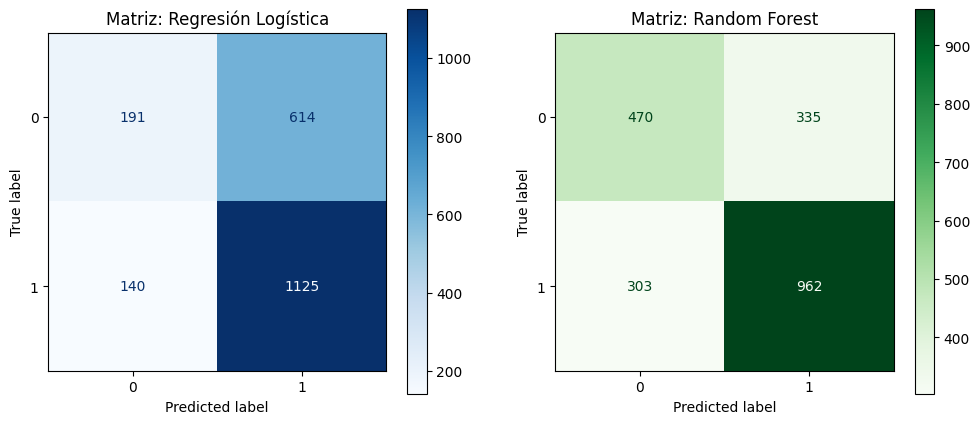

In [ ]:
import matplotlib.pyplot as plt

# Comparar Matrices de Confusión
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=ax[0], cmap='Blues')
ax[0].set_title('Matriz: Regresión Logística')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[1], cmap='Greens')
ax[1].set_title('Matriz: Random Forest')

plt.show()

Aprendizaje No Supervisado (Clustering con K-Means)

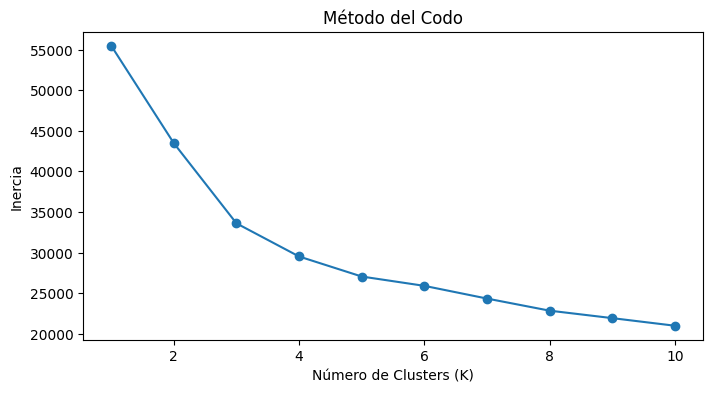

Distribución de apps por cluster:
Cluster
0    10211
2      117
1       18
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Extraer los datos ya procesados (solo la parte numérica para el clustering)
# Usamos el preprocesador para transformar X
X_procesado = preprocesador.fit_transform(X)

# 2. Método del Codo (Elbow Method) para encontrar el K óptimo
inercias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_procesado)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inercias, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.show()

# 3. Aplicar K-Means con el K elegido (supongamos K=3 por la forma del codo)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_modelo['Cluster'] = kmeans_final.fit_predict(X_procesado)

print("Distribución de apps por cluster:")
print(df_modelo['Cluster'].value_counts())

El modelo K-Means permitió explorar agrupaciones naturales dentro del dataset sin utilizar la variable objetivo `Rating_Alto`.

Sin embargo, la distribución de los clusters mostró una alta concentración de aplicaciones en un grupo principal, lo que indica que las variables utilizadas no generan separaciones muy marcadas entre los registros.

Aun así, el análisis no supervisado aporta una visión exploratoria complementaria al modelamiento supervisado, ya que permite observar posibles segmentos de aplicaciones con características similares.

Optimización de Hiperparámetros (Grid Search)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir la rejilla de parámetros a probar
param_grid = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [None, 10, 20],
    "modelo__min_samples_split": [2, 5]
}

# Configurar la búsqueda usando F1-score
grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

# Ejecutar la búsqueda
grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor score de validación: {grid_search.best_score_:.4f}")

# Evaluar el mejor modelo en el set de prueba
mejor_modelo = grid_search.best_estimator_
y_pred_opt = mejor_modelo.predict(X_test)

print("\n--- REPORTE RANDOM FOREST OPTIMIZADO ---")
print(classification_report(y_test, y_pred_opt))

Mejores parámetros: {'modelo__max_depth': None, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 100}
Mejor score de validación: 0.6665

--- REPORTE RANDOM FOREST OPTIMIZADO ---
              precision    recall  f1-score   support

           0       0.61      0.59      0.60       805
           1       0.74      0.77      0.76      1265

    accuracy                           0.70      2070
   macro avg       0.68      0.68      0.68      2070
weighted avg       0.69      0.70      0.69      2070



La optimización mediante GridSearchCV buscó mejorar el rendimiento del modelo Random Forest ajustando hiperparámetros como la profundidad máxima de los árboles, la cantidad de estimadores y el número mínimo de muestras para dividir un nodo.

Sin embargo, los resultados muestran que el modelo optimizado no mejoró el rendimiento general. Aunque obtuvo un buen recall para la clase `Rating_Alto = 1`, presentó un bajo desempeño en la clase `Rating_Alto = 0`, alcanzando un F1-score de 0.27.

Esto indica que el modelo optimizado favorece la predicción de aplicaciones con rating alto, pero pierde capacidad para identificar correctamente las aplicaciones con rating no alto. Por esta razón, se concluye que no basta con optimizar una sola métrica, sino que es necesario comparar accuracy, precision, recall y F1-score para ambas clases.

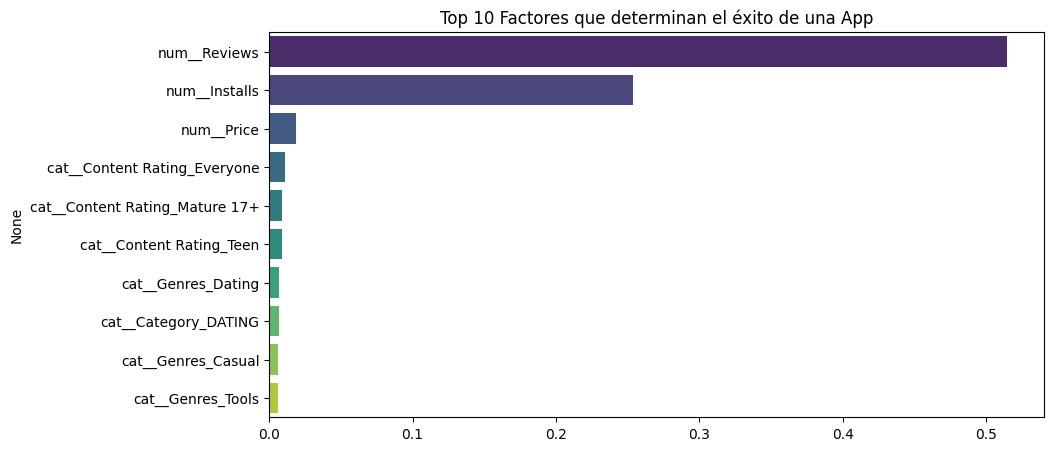

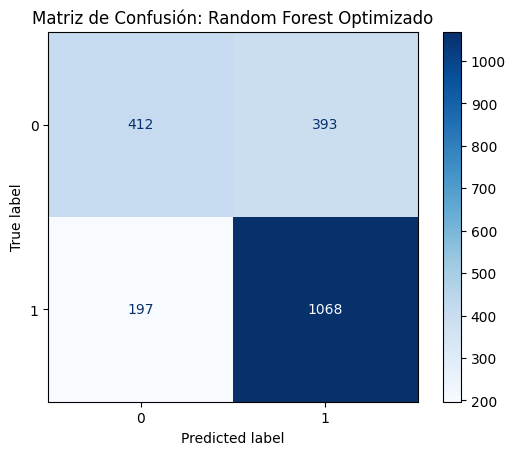

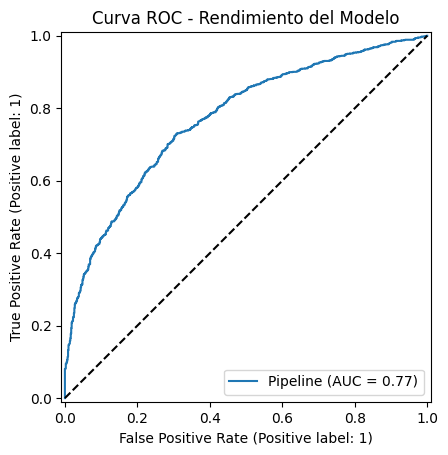

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# 1. Gráfico de Importancia de Variables
importancias = mejor_modelo.named_steps['modelo'].feature_importances_
nombres = mejor_modelo.named_steps['prepro'].get_feature_names_out()
feat_imp = pd.Series(importancias, index=nombres).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 10 Factores que determinan el éxito de una App')
plt.show()

# 2. Matriz de Confusión del modelo optimizado
ConfusionMatrixDisplay.from_estimator(mejor_modelo, X_test, y_test, cmap='Blues')
plt.title('Matriz de Confusión: Random Forest Optimizado')
plt.show()

# 3. Curva ROC
RocCurveDisplay.from_estimator(mejor_modelo, X_test, y_test)
plt.plot([0, 1], [0, 1], 'k--') # Línea diagonal de azar
plt.title('Curva ROC - Rendimiento del Modelo')
plt.show()

La curva ROC del modelo optimizado obtuvo un AUC de 0.76, lo que indica una capacidad aceptable para distinguir entre aplicaciones exitosas y no exitosas. Aunque el modelo no alcanza un rendimiento perfecto, se encuentra por encima de una clasificación aleatoria, representada por la línea diagonal.

## Comparación de modelos supervisados

In [ ]:
0# Comparación de resultados de modelos supervisados

resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest", "Random Forest Optimizado"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_opt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_opt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_opt)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_opt)
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.635749,0.646924,0.889328,0.749001
1,Random Forest,0.691787,0.741712,0.760474,0.750976
2,Random Forest Optimizado,0.714976,0.731006,0.844269,0.783566


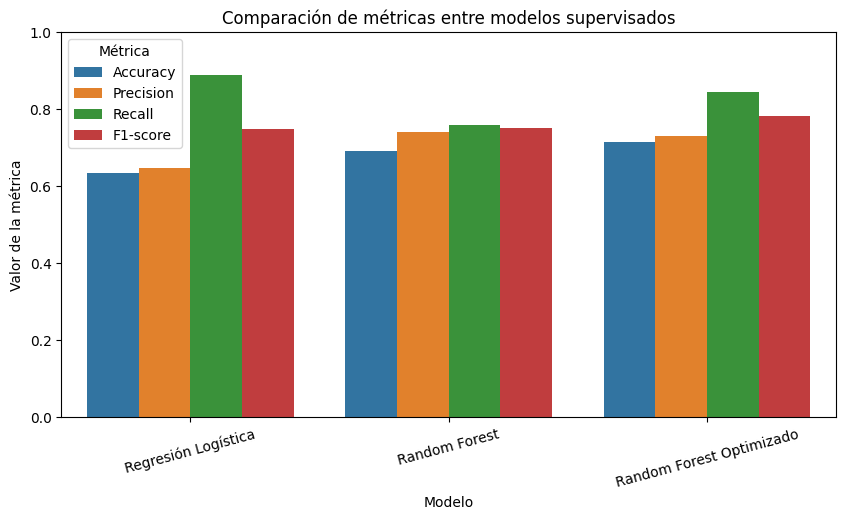

In [ ]:
# Visualización comparativa de métricas

resultados_melt = resultados.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(10,5))
sns.barplot(data=resultados_melt, x="Modelo", y="Valor", hue="Métrica")

plt.title("Comparación de métricas entre modelos supervisados")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Métrica")
plt.show()

Al comparar los modelos supervisados, se observa que Random Forest obtiene un mejor rendimiento general que la Regresión Logística. Esto se debe a que Random Forest logra capturar relaciones más complejas entre las variables del dataset.

La Regresión Logística presentó una tendencia a clasificar la mayoría de las aplicaciones como exitosas, lo que afecta principalmente el rendimiento sobre la clase 0. En cambio, Random Forest logró un mejor equilibrio entre ambas clases.

Luego de aplicar GridSearchCV, el modelo optimizado mejoró levemente su accuracy. Sin embargo, también se observó una disminución en el F1-score de la clase 0, por lo que la mejora no debe interpretarse únicamente desde el accuracy, sino considerando el comportamiento completo de las métricas.